In [1]:
# import part
from src.agent_class import Agent
from src.map_class import Map2 
from src.center_class import Center
from src.order_class import Order
from src.Astar_route import a_star

import osmnx as ox
import random
import matplotlib.pyplot as plt
import japanize_matplotlib


In [2]:
# config part
location = "神奈川県横浜市港南区"
num_agent = 3
gen_prob = 0.3
deadtime = 100
vehicle_speed = 30
attitude = a_star
agents = {}
current_time = 0

log_filename = "simulation_log_006.csv"

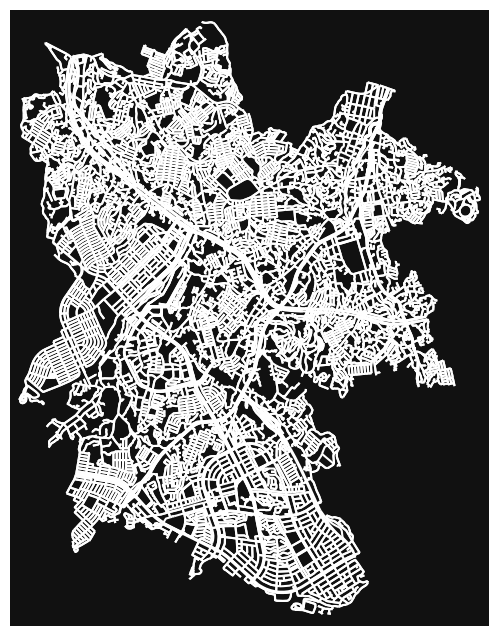

In [3]:
# osmnx kidou
G = ox.graph_from_place(location,network_type="all")

fig, ax = ox.plot_graph(
    G, 
    node_size=0,          
    edge_linewidth=1.5,   
    edge_color="#FFFFFF"  
)

In [5]:
# imamadeni tukutta map ni utusu sagyou
sim_map = Map2(place_name=location)

OSMからデータを取得中: 神奈川県横浜市港南区 (all)...
マップ生成完了: ノード数 10268


In [7]:
node_list = sim_map.node_list
for i in range(num_agent):
    start_node = random.choice(node_list)
    agent_id = f"AMR_{i}"

    agents[i] = Agent(
        agent_id = agent_id,
        start_node= start_node,
        vehicle_speed=vehicle_speed,
        attitude=attitude
    )

#スタートノードが被る可能性があるけど一旦いいや
print("--- エージェント初期化完了 ---")
for idx, ag in agents.items():
    print(f"Index: {idx} | ID: {ag.agent_id} | 現在地ノード: {ag.current_node} | 速度: {ag.speed}")

--- エージェント初期化完了 ---
Index: 0 | ID: AMR_0 | 現在地ノード: 8281 | 速度: 30
Index: 1 | ID: AMR_1 | 現在地ノード: 471 | 速度: 30
Index: 2 | ID: AMR_2 | 現在地ノード: 3886 | 速度: 30


In [ ]:
center = Center(sim_map=sim_map, agents=agents, allocation_method="Euclid", log_filename=log_filename)

print("全クラス完全統合シミュレーションを開始します... (Ctrl+C で停止)")

try:
    while True:
        # ① マップの動的渋滞変化を更新
        sim_map.update()

        # ② 新しいオーダーの発生チェック
        center.try_generate_order(current_time, deadtime, sim_map.num_node, gen_prob)

        # ③ オーダーの自動配分マッチング
        center.allocation_order()

        # ④ 全エージェントの時間を1秒進める（移動処理 ＆ イベント駆動リプランニング）
        for ag in agents.values():
            ag.update(sim_map)

        # ⑤ 完了したオーダーのCSV追記保存 ＆ メモリ解放
        center.csv_save()

        # ⑥ センター画面の描画更新（2画面分割の動的ダッシュボードアニメーション！）
        center.visualize(current_time)

        current_time += 1
        time.sleep(0.2)

except KeyboardInterrupt:
    print("\nシミュレーションを終了しました。")

全クラス完全統合シミュレーションを開始します... (Ctrl+C で停止)
